A validação cruzada utilizando a base de dados MNIST com redes neurais convolucionais

In [24]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/YouTube/bin/python


In [25]:
import sys
print(sys.version)

3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:31:09) [GCC 11.2.0]


# Projeto 12: Validação Cruzada - Rede Neural Convolucional MNIST

In [1]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from sklearn.model_selection import cross_val_score
import torchvision.transforms as transforms
from skorch import NeuralNetClassifier
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

In [2]:
torch.manual_seed(123)

In [3]:
transform = transforms.ToTensor()

In [5]:
train = datasets.MNIST(root = '.', train = True, download=True, transform=transform)

In [4]:
#!pip install skorch

## Etapa 3: Construção do modelo

In [9]:
class classificador_torch(nn.Module):
  def __init__(self):
    super().__init__()

    # --- EXTRAÇÃO DE CARACTERÍSTICAS (CNN) ---
    # conv1 e conv2: Criam 32 mapas de características usando filtros 3x3.
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3))
    self.conv2 = nn.Conv2d(32, 32, (3, 3))
    
    self.activation = nn.ReLU()      # Ativação: Mantém apenas valores positivos.
    self.bnorm = nn.BatchNorm2d(32)  # Normalização: Acelera o treino e estabiliza camadas.
    self.pool = nn.MaxPool2d(2,2)    # Pooling: Reduz o tamanho da imagem pela metade.
    self.flatten = nn.Flatten()      # Flatten: Achata a matriz 3D para um vetor 1D.

    # --- CLASSIFICAÇÃO (Densa/Linear) ---
    # linear1/2: Camadas ocultas com 128 neurônios para processar os padrões extraídos.
    self.linear1 = nn.Linear(in_features=32*5*5, out_features=128)
    self.linear2 = nn.Linear(128, 128)
    # output: Camada final com 10 neurônios (um para cada classe/número).
    self.output = nn.Linear(128, 10)
    # dropout: Desliga 20% dos neurônios aleatoriamente para evitar overfitting (decoreba).
    self.dropout = nn.Dropout(p = 0.2)

  def forward(self, X):
    # REDIMENSIONAMENTO: Garante que o input seja (Lote, Canal, Altura, Largura).
    ##### Tem que transformar as imagens no formato que as CNNs operam no PyTorch: (batch_size, n_dimensions, width, height)
    X = X.view(-1, 1, 28, 28) 
    
    # FLUXO CONVOLUCIONAL: Conv -> Ativa -> Normaliza -> Reduz.
    X = self.pool(self.bnorm(self.activation(self.conv1(X))))
    X = self.pool(self.bnorm(self.activation(self.conv2(X))))
    X = self.flatten(X)

    # FLUXO DENSO: Processa os vetores e aplica dropout antes da decisão final.
    X = self.dropout(self.activation(self.linear1(X)))
    X = self.dropout(self.activation(self.linear2(X)))
    X = self.output(X)

    return X

In [13]:
# Criando o wrapper (envelope) Skorch para a rede PyTorch
classificador_sklearn = NeuralNetClassifier(
    module = classificador_torch,        # Define qual é a arquitetura da rede (a classe que você criou)
    criterion = torch.nn.CrossEntropyLoss, # Função de erro (Loss) para classificação multicalsse
    optimizer = torch.optim.Adam,        # Otimizador que ajusta os pesos (Adam é rápido e eficiente)
    max_epochs = 3,                      # Número de vezes que a rede verá o dataset inteiro
    batch_size = 10,                     # Processa 10 imagens por vez antes de atualizar os pesos
    train_split = False                  # Desativa a divisão automática de validação do Skorch 
                                         # (útil se você já tiver um conjunto de teste separado)
)

In [14]:
classificador_sklearn

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.classificador_torch'>,
)

In [15]:
classificador_sklearn.get_params()

{'module': __main__.classificador_torch,
 'criterion': torch.nn.modules.loss.CrossEntropyLoss,
 'optimizer': torch.optim.adam.Adam,
 'lr': 0.01,
 'max_epochs': 3,
 'batch_size': 10,
 'iterator_train': torch.utils.data.dataloader.DataLoader,
 'iterator_valid': torch.utils.data.dataloader.DataLoader,
 'dataset': skorch.dataset.Dataset,
 'train_split': False,
 'callbacks': None,
 'predict_nonlinearity': 'auto',
 'warm_start': False,
 'verbose': 1,
 'device': 'cpu',
 'compile': False,
 'use_caching': 'auto',
 'torch_load_kwargs': None,
 '_params_to_validate': set(),
 'classes': None,
 'callbacks__epoch_timer': <skorch.callbacks.logging.EpochTimer at 0x74ebeb301b80>,
 'callbacks__train_loss': <skorch.callbacks.scoring.PassthroughScoring at 0x74ebeb1306b0>,
 'callbacks__train_loss__name': 'train_loss',
 'callbacks__train_loss__lower_is_better': True,
 'callbacks__train_loss__on_train': True,
 'callbacks__valid_loss': <skorch.callbacks.scoring.PassthroughScoring at 0x74ebeb130050>,
 'callback

## Etapa 4: Validação cruzada

In [16]:
##### Primeiro temos que mudar os tipos dos dados de X e y para corresponderem aos tipos dos pesos usados na rede.
X = train.data.type('torch.FloatTensor')
y = train.targets.type('torch.LongTensor')

In [17]:
train

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: ToTensor()

In [19]:
# Realizando a validação cruzada para medir a performance real do modelo
resultados = cross_val_score(
    classificador_sklearn, # O seu modelo (o wrapper Skorch que criamos)
    X,                     # Suas imagens (em formato NumPy)
    y,                     # Suas etiquetas/classes (gabarito)
    cv = 5,                # K-Fold: Divide os dados em 5 partes e treina 5 vezes
    scoring = 'accuracy'   # Métrica: Queremos saber a porcentagem de acertos (acurácia)
)

  epoch    train_loss      dur
-------  ------------  -------
      1        0.4373  29.6374
      2        0.3904  34.3921
      3        0.3541  45.3805
  epoch    train_loss      dur
-------  ------------  -------
      1        0.4279  35.6527
      2        0.3721  48.7999
      3        0.3819  49.3664
  epoch    train_loss      dur
-------  ------------  -------
      1        0.4140  41.1692
      2        0.3812  34.1721
      3        0.4430  42.7369
  epoch    train_loss      dur
-------  ------------  -------
      1        0.3987  49.3093
      2        0.3585  53.0269
      3        0.3631  71.6201
  epoch    train_loss      dur
-------  ------------  -------
      1        0.4200  63.8230
      2        0.4218  71.0310
      3        0.4046  83.7907


In [20]:
print(f"Acurácia Média: {resultados.mean():.4f}")
print(f"Desvio Padrão: {resultados.std():.4f}")

Acurácia Média: 0.6361
Desvio Padrão: 0.1154


In [21]:
media = resultados.mean()
desvio = resultados.std()

In [22]:
media, desvio

(0.63615, 0.11542129834268505)

In [23]:
resultados

array([0.78325   , 0.46175   , 0.69416667, 0.54758333, 0.694     ])

In [26]:
# Mostra o local dos arquivos, número de imagens e as transformações aplicadas
print(train)

# Ver as classes (0 a 9)
print(train.classes)

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: ToTensor()
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [27]:
# Pega a primeira imagem e o gabarito (label) dela
imagem, rotulo = train[0]

print(f"Formato do Tensor: {imagem.shape}") # Ex: [1, 28, 28]
print(f"Classe (Target): {rotulo}")        # Ex: 5

Formato do Tensor: torch.Size([1, 28, 28])
Classe (Target): 5


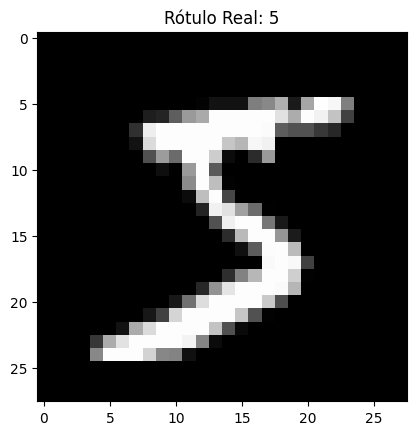

In [28]:
import matplotlib.pyplot as plt

# Pegamos a imagem 0
imagem, rotulo = train[0]

# .squeeze() remove a dimensão de canal [1, 28, 28] -> [28, 28]
plt.imshow(imagem.squeeze(), cmap='gray')
plt.title(f'Rótulo Real: {rotulo}')
plt.show()